In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

REPO_ROOT = Path("..")
SLIDES_DIR = REPO_ROOT / "output" / "slides"
SLIDES_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_PATH = REPO_ROOT / "output" / "forecast_final.csv"
TEMPLATE_PATH = REPO_ROOT / "template_forecast_v00.csv"
STAFFING_PATH = REPO_ROOT / "data" / "processed" / "staffing.csv"

PORTFOLIOS = ["A", "B", "C", "D"]
COLORS = ["#323232", "#5DADE2", "#FFC500", "#E74C3C"]

forecast = pd.read_csv(FORECAST_PATH)
template = pd.read_csv(TEMPLATE_PATH)
print(f"Forecast: {forecast.shape}  |  Template: {template.shape}")

Forecast: (1488, 19)  |  Template: (1488, 19)


In [4]:
assert forecast.shape == template.shape, f"Shape mismatch: {forecast.shape} vs {template.shape}"
assert list(forecast.columns) == list(template.columns), "Column mismatch"

issues = []
for p in PORTFOLIOS:
    if (forecast[f"Calls_Offered_{p}"] < 0).any():  issues.append(f"{p}: negative CV")
    if (forecast[f"CCT_{p}"] < 0).any():             issues.append(f"{p}: negative CCT")
    if (forecast[f"Abandoned_Rate_{p}"] < 0).any():  issues.append(f"{p}: negative ABD")
    if (forecast[f"Abandoned_Rate_{p}"] > 1).any():  issues.append(f"{p}: ABD > 1")

if issues:
    print("ISSUES FOUND:"); [print(" ", i) for i in issues]
else:
    print("All validation checks passed.")
print(f"Rows: {len(forecast)} (expected 1488 = 31 days × 48 slots)")

All validation checks passed.
Rows: 1488 (expected 1488 = 31 days × 48 slots)


In [5]:
aug_dates = pd.date_range("2025-08-01", "2025-08-31", freq="D")
forecast["_Date"] = np.repeat(aug_dates, 48)
forecast["_SlotIndex"] = list(range(48)) * 31

daily_agg = {}
for p in PORTFOLIOS:
    daily_agg[p] = forecast.groupby("_Date").agg(
        CV_sum  =(f"Calls_Offered_{p}",  "sum"),
        CCT_mean=(f"CCT_{p}",            "mean"),
        ABD_mean=(f"Abandoned_Rate_{p}", "mean"),
    ).reset_index()

print(f"{'Portfolio':<10} {'Avg Daily CV':>14} {'Avg CCT (s)':>12} {'Avg ABD':>10} {'Monthly CV':>12}")
print("-" * 54)
for p in PORTFOLIOS:
    d = daily_agg[p]
    print(f"{p:<10} {d['CV_sum'].mean():>14,.0f} {d['CCT_mean'].mean():>12.1f} {d['ABD_mean'].mean():>10.4f} {d['CV_sum'].sum():>12,.0f}")

Portfolio    Avg Daily CV  Avg CCT (s)    Avg ABD   Monthly CV
------------------------------------------------------
A                   3,878        312.4     0.0212      120,214
B                   8,639        319.7     0.0168      267,805
C                  19,875        323.0     0.0089      616,113
D                  10,382        311.7     0.0137      321,837


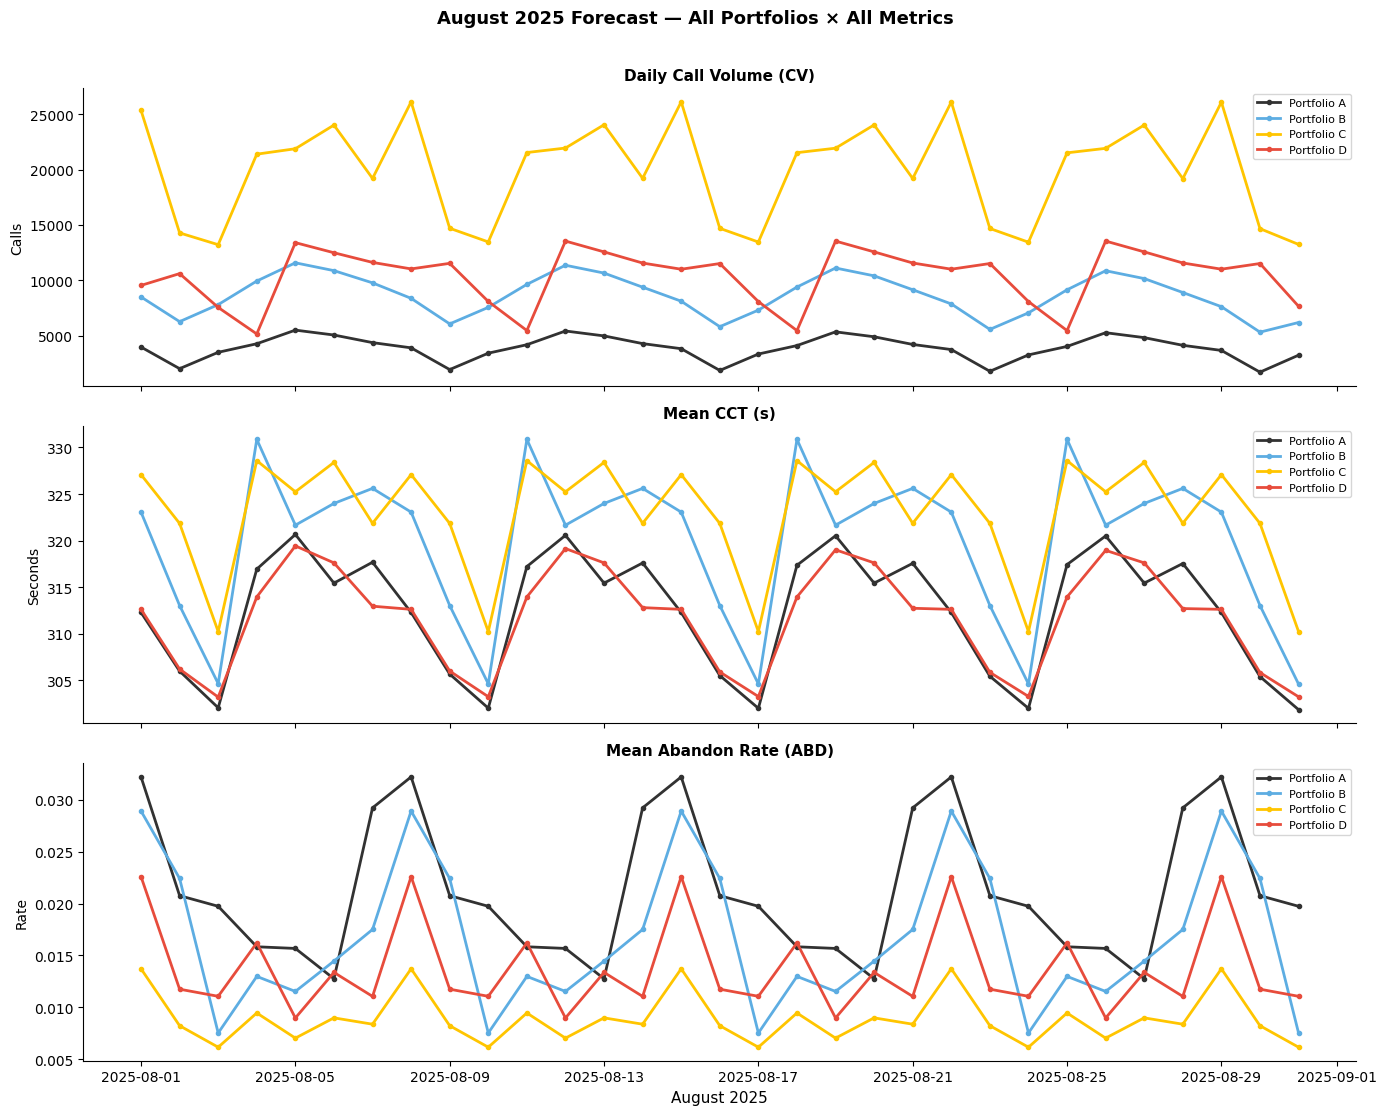

Saved slide7_results_all_metrics.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
metrics = [
    ("CV_sum",   "Daily Call Volume (CV)",   "Calls"),
    ("CCT_mean", "Mean CCT (s)",             "Seconds"),
    ("ABD_mean", "Mean Abandon Rate (ABD)",  "Rate"),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    for i, p in enumerate(PORTFOLIOS):
        d = daily_agg[p]
        ax.plot(d["_Date"], d[col], label=f"Portfolio {p}",
                color=COLORS[i], linewidth=2, marker="o", markersize=3)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("August 2025", fontsize=11)
fig.suptitle("August 2025 Forecast — All Portfolios × All Metrics",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide7_results_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved slide7_results_all_metrics.png")

In [7]:
staffing = pd.read_csv(STAFFING_PATH, parse_dates=["Date"])
aug_staffing = staffing[(staffing["Date"] >= "2025-08-01") & (staffing["Date"] <= "2025-08-31")].copy()
staff_cols = [c for c in aug_staffing.columns if c != "Date"]
UTILIZATION = 0.85
SHIFT_SECONDS = 8 * 3600
print(f"Aug staffing rows: {len(aug_staffing)}, cols: {staff_cols}")

Aug staffing rows: 31, cols: ['A', 'B', 'C', 'D']


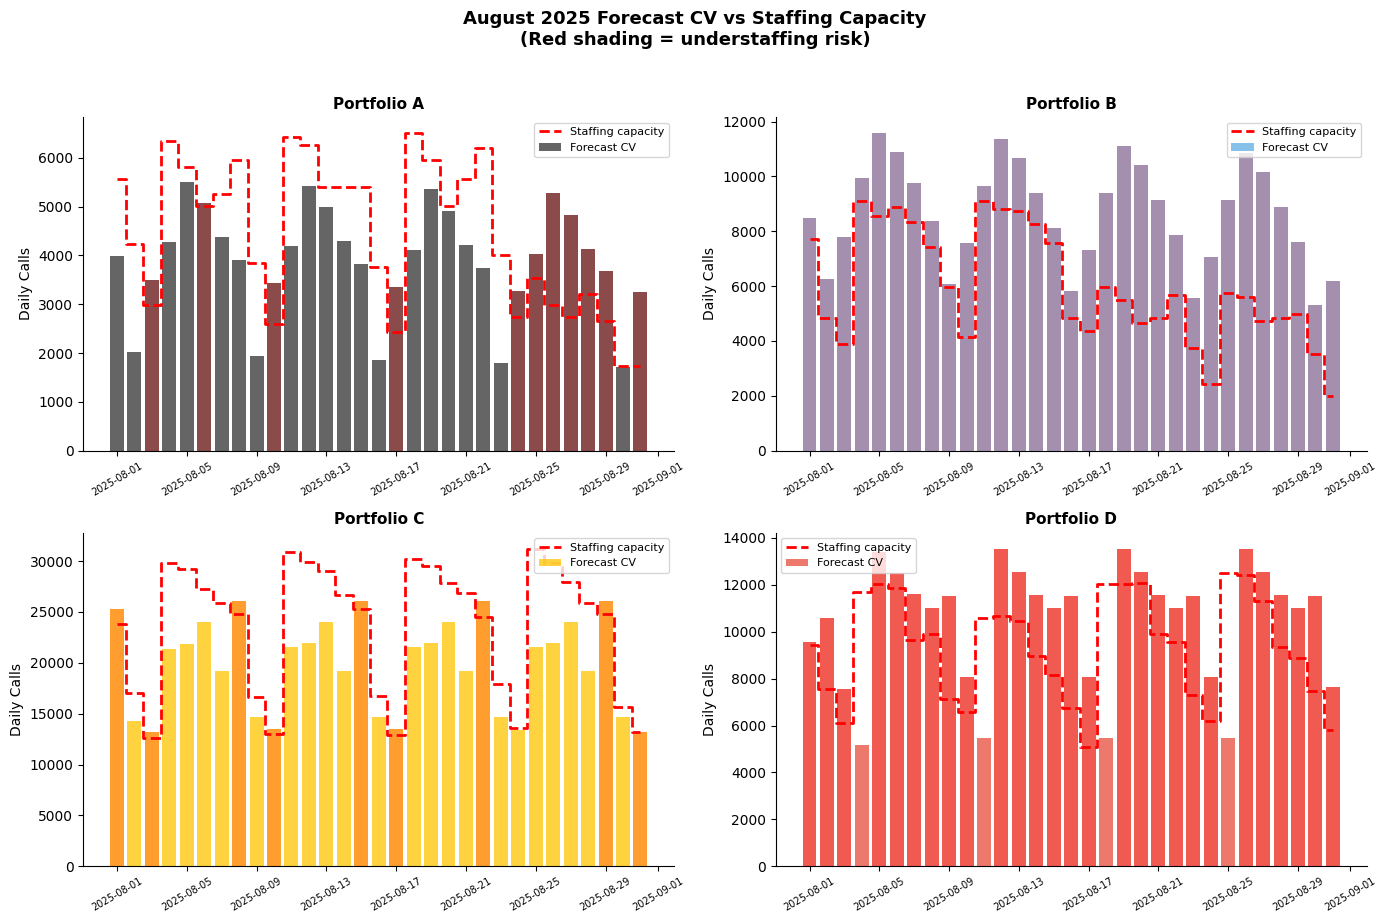

Saved slide8_staffing_impact.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

for i, p in enumerate(PORTFOLIOS):
    ax = axes[i]
    d = daily_agg[p].set_index("_Date")
    avg_cct = d["CCT_mean"].mean()

    p_staff_col = next((c for c in staff_cols if p in c), staff_cols[0] if staff_cols else None)
    dates = d.index
    cv = d["CV_sum"].values

    if p_staff_col and p_staff_col in aug_staffing.columns:
        merged = d.merge(aug_staffing[["Date", p_staff_col]].rename(columns={"Date": "_Date"}),
                         left_index=True, right_on="_Date", how="left")
        agents = merged[p_staff_col].fillna(0).values
        capacity = agents * UTILIZATION * SHIFT_SECONDS / max(avg_cct, 1)
        has_staffing = True
    else:
        capacity = None
        has_staffing = False

    ax.bar(dates, cv, color=COLORS[i], alpha=0.75, label="Forecast CV", width=0.8)

    if has_staffing and capacity is not None:
        ax.step(dates, capacity, where="mid", color="red", linewidth=2,
                linestyle="--", label="Staffing capacity")
        for d_val, c_val, cv_val in zip(dates, capacity, cv):
            if cv_val > c_val:
                ax.bar(d_val, cv_val, color="red", alpha=0.25, width=0.8)

    ax.set_title(f"Portfolio {p}", fontweight="bold", fontsize=11)
    ax.set_ylabel("Daily Calls")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8)

fig.suptitle("August 2025 Forecast CV vs Staffing Capacity\n(Red shading = understaffing risk)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide8_staffing_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved slide8_staffing_impact.png")

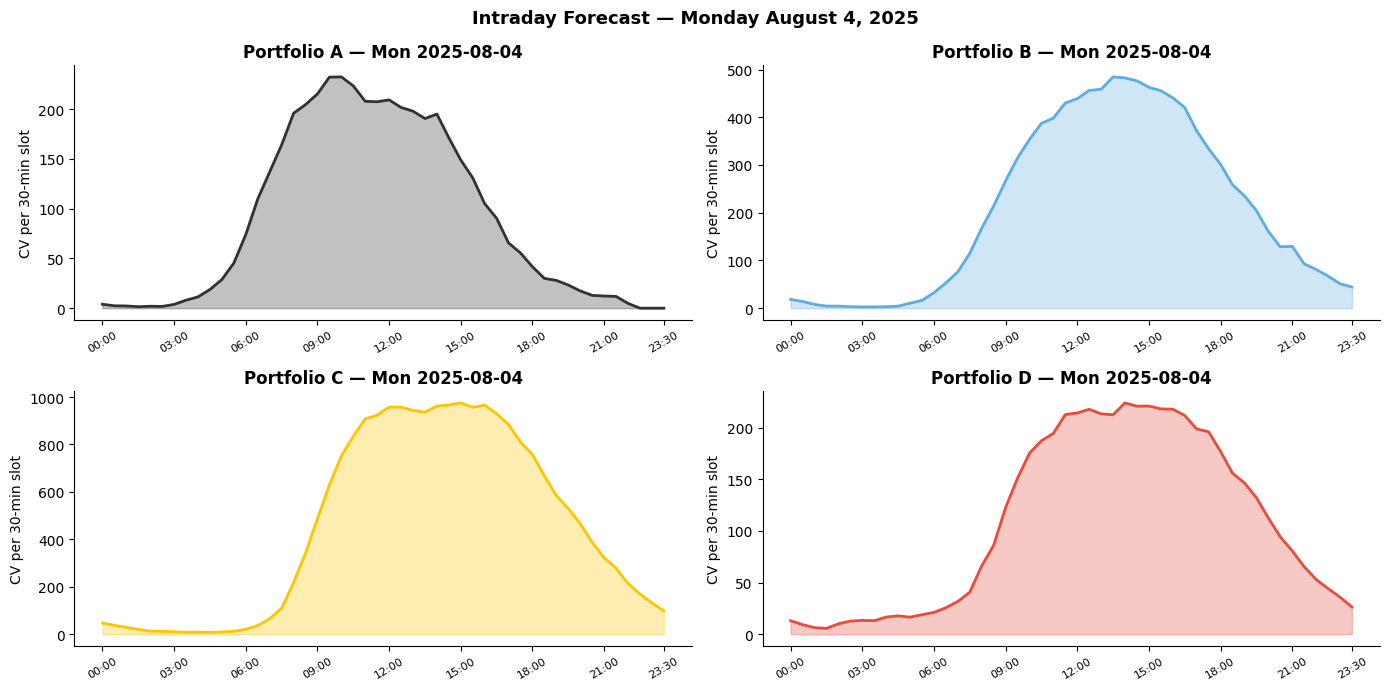

Saved slide7_intraday_preview.png


In [9]:
slot_labels = [f"{h:02d}:{m}" for h in range(24) for m in ("00", "30")]
sample_date = pd.Timestamp("2025-08-04")  # Monday
sample_rows = forecast[forecast["_Date"] == sample_date].sort_values("_SlotIndex")

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for i, p in enumerate(PORTFOLIOS):
    ax = axes[i]
    cv = sample_rows[f"Calls_Offered_{p}"].values
    ax.fill_between(range(48), cv, alpha=0.3, color=COLORS[i])
    ax.plot(range(48), cv, color=COLORS[i], linewidth=2)
    ax.set_title(f"Portfolio {p} — Mon 2025-08-04", fontweight="bold")
    ax.set_ylabel("CV per 30-min slot")
    ax.set_xticks([0, 6, 12, 18, 24, 30, 36, 42, 47])
    ax.set_xticklabels([slot_labels[s] for s in [0, 6, 12, 18, 24, 30, 36, 42, 47]],
                       rotation=30, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Intraday Forecast — Monday August 4, 2025",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SLIDES_DIR / "slide7_intraday_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved slide7_intraday_preview.png")

In [10]:
import shutil

submission_path = REPO_ROOT / "output" / "submission_final.csv"

out = forecast.drop(columns=["_Date", "_SlotIndex"], errors="ignore")
out.to_csv(submission_path, index=False)
print(f"Submission saved: {submission_path}")
print(f"Shape: {out.shape}")
print(out.head(3))

Submission saved: ../output/submission_final.csv
Shape: (1488, 19)
    Month  Day Interval  Calls_Offered_A  Abandoned_Calls_A  Abandoned_Rate_A  \
0  August    1     0:00         5.270037                0.0               0.0   
1  August    1     0:30         4.038080                0.0               0.0   
2  August    1     1:00         3.079892                0.0               0.0   

        CCT_A  Calls_Offered_B  Abandoned_Calls_B  Abandoned_Rate_B  \
0  355.653077        29.510248           0.000000            0.0000   
1  342.039231        20.535112           0.000000            0.0000   
2  294.850769         9.046937           0.198128            0.0219   

        CCT_B  Calls_Offered_C  Abandoned_Calls_C  Abandoned_Rate_C  \
0  317.410769        87.249148           0.197317          0.002262   
1  280.547692        57.853041           0.396961          0.006862   
2  409.310000        44.892457           1.177218          0.026223   

        CCT_C  Calls_Offered_D  Abando